In [1]:
from itertools import count

import pandas as pd

print('Загрузка данных')
df = pd.read_excel('OnlineRetail.xlsx')
print('Загрузка завершена!')

df.head()

Загрузка данных
Загрузка завершена!


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [2]:
df_sample = df.sample(frac=0.1, random_state=42).copy()

df_sample.shape

(54191, 8)

In [3]:
df_sample.isnull().sum()

InvoiceNo          0
StockCode          0
Description      149
Quantity           0
InvoiceDate        0
UnitPrice          0
CustomerID     13640
Country            0
dtype: int64

In [5]:
df_clean = df_sample.dropna(subset=['Description', 'CustomerID']).copy()

df_clean.shape

(40551, 8)

In [9]:
df_clean[["Quantity", 'UnitPrice']].describe()

,Quantity,UnitPrice
count,40551.000000,40551.000000
mean,13.620059,3.300404
std,370.747950,27.329013
min,-1350.000000,0.000000
25%,2.000000,1.250000
50%,5.000000,1.950000
75%,12.000000,3.750000
max,74215.000000,4161.060000


In [10]:
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)].copy()

df_clean.shape

(39635, 8)

In [11]:
df_clean.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

In [12]:
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int).astype(str)

df_clean['CustomerID'].head()

209268    17315
207108    14031
167085    14031
471836    17198
115865    13502
Name: CustomerID, dtype: str

In [13]:
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['UnitPrice']

df_clean[['Quantity', 'UnitPrice', 'Revenue']].head()

,Quantity,UnitPrice,Revenue
209268,24,0.85,20.40
207108,4,6.95,27.80
167085,4,0.65,2.60
471836,3,1.95,5.85
115865,2,9.95,19.90


In [15]:
country_metrics = (
    df_clean.groupby('Country')
    .agg(total_revenue=('Revenue', 'sum'), order_count=("InvoiceNo", "nunique"))
    .sort_values(by='total_revenue', ascending=False)
)

country_metrics.head(10)

,total_revenue,order_count
Country,,
United Kingdom,768682.561,11507
Netherlands,27435.830,67
EIRE,24340.420,210
France,23606.730,287
Germany,22389.510,319
Australia,12429.990,34
Spain,5600.900,70
Switzerland,5383.190,39
Belgium,3593.510,72


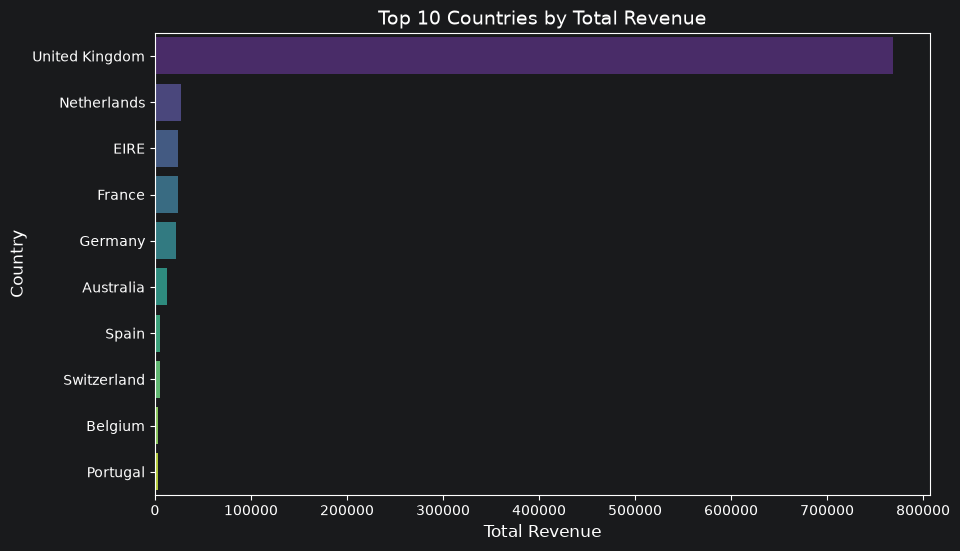

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Берем топ-10 стран и сбрасываем индекс для удобства построения
top_10 = country_metrics.head(10).reset_index()

# Настраиваем размер графика
plt.figure(figsize=(10, 6))

# Строим горизонтальный столбчатый график
sns.barplot(
    data=top_10,
    x="total_revenue",
    y="Country",
    hue="Country",
    palette="viridis",
    legend=False,
)
# Добавляем подписи и заголовок
plt.title("Top 10 Countries by Total Revenue", fontsize=14)
plt.xlabel("Total Revenue", fontsize=12)
plt.ylabel("Country", fontsize=12)

# Отображаем график
plt.show()